In [7]:
# Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição e estética
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', None)

In [2]:
# Definindo os caminhos dos arquivos
path_game = r"C:\Users\alice\OneDrive\Documentos\Data Science\DATASETS - ATVD 3\world_olympedia_olympics_game.csv\world_olympedia_olympics_game.csv"
path_tally = r"C:\Users\alice\OneDrive\Documentos\Data Science\DATASETS - ATVD 3\world_olympedia_olympics_game_medal_tally.csv\world_olympedia_olympics_game_medal_tally.csv"
path_paris = r"C:\Users\alice\OneDrive\Documentos\Data Science\DATASETS - ATVD 3\archive (1)\medals_total.csv"

# Carregando os DataFrames
df_game = pd.read_csv(path_game)
df_tally = pd.read_csv(path_tally)
df_paris_raw = pd.read_csv(path_paris)

In [3]:
# Processamento e Consolidação
# Tratando o Histórico (1896-2022)
df_hist_unido = pd.merge(df_tally, df_game[['edition_id', 'edition']], on='edition_id')
df_hist_unido['season'] = df_hist_unido['edition_y'].apply(lambda x: 'Summer' if 'Summer' in x else 'Winter')

df_hist_limpo = df_hist_unido[['country_noc', 'season', 'gold', 'silver', 'bronze']].copy()
df_hist_limpo.columns = ['noc', 'season', 'gold', 'silver', 'bronze']

# Tratando Paris 2024
df_paris = df_paris_raw[['country_code', 'Gold Medal', 'Silver Medal', 'Bronze Medal']].copy()
df_paris.columns = ['noc', 'gold', 'silver', 'bronze']
df_paris['season'] = 'Summer'

# Requisito 1.1: TABELAS ORDENADAS POR TOTAL DE MEDALHAS 

# 1. Medalhas – Jogos de Verão
verao_all = pd.concat([df_hist_limpo[df_hist_limpo['season'] == 'Summer'], df_paris])
tabela_verao_final = verao_all.groupby('noc')[['gold', 'silver', 'bronze']].sum().reset_index()
tabela_verao_final['total'] = tabela_verao_final['gold'] + tabela_verao_final['silver'] + tabela_verao_final['bronze']
tabela_verao_final = tabela_verao_final.sort_values(by='total', ascending=False).reset_index(drop=True)

# 2. Medalhas – Jogos de Inverno
winter_only = df_hist_limpo[df_hist_limpo['season'] == 'Winter']
tabela_inverno_final = winter_only.groupby('noc')[['gold', 'silver', 'bronze']].sum().reset_index()
tabela_inverno_final['total'] = tabela_inverno_final['gold'] + tabela_inverno_final['silver'] + tabela_inverno_final['bronze']
tabela_inverno_final = tabela_inverno_final.sort_values(by='total', ascending=False).reset_index(drop=True)

# 3. Medalhas – Total Geral
tabela_geral_final = pd.concat([tabela_verao_final, tabela_inverno_final]).groupby('noc')[['gold', 'silver', 'bronze', 'total']].sum().reset_index()
tabela_geral_final = tabela_geral_final.sort_values(by='total', ascending=False).reset_index(drop=True)


In [4]:
# Exibição das Tabelas
print("1.1.1 MEDALHAS – JOGOS DE VERÃO")
display(tabela_verao_final)

print("\n1.1.2 MEDALHAS – JOGOS DE INVERNO")
display(tabela_inverno_final)

print("\n1.1.3 MEDALHAS – TOTAL GERAL")
display(tabela_geral_final)

1.1.1 MEDALHAS – JOGOS DE VERÃO


,noc,gold,silver,bronze,total
0,USA,1110,885,786,2781
1,URS,395,319,296,1010
2,GBR,305,345,342,992
3,FRA,247,283,307,837
4,GER,249,277,298,824
5,CHN,303,226,198,727
6,ITA,234,206,229,669
7,AUS,180,189,225,594
8,JPN,189,162,193,544
9,HUN,188,163,183,534



1.1.2 MEDALHAS – JOGOS DE INVERNO


,noc,gold,silver,bronze,total
0,NOR,149,135,123,407
1,USA,125,128,101,354
2,GER,118,113,76,307
3,AUT,74,91,94,259
4,CAN,78,73,77,228
5,URS,78,57,59,194
6,SWE,70,56,67,193
7,FIN,47,66,66,179
8,FRA,56,51,71,178
9,SUI,67,50,60,177



1.1.3 MEDALHAS – TOTAL GERAL


,noc,gold,silver,bronze,total
0,USA,1235,1013,887,3135
1,URS,473,376,355,1204
2,GER,367,390,374,1131
3,GBR,326,361,366,1053
4,FRA,303,334,378,1015
5,ITA,283,257,289,829
6,CHN,325,258,221,804
7,SWE,220,237,251,708
8,JPN,206,190,224,620
9,AUS,186,196,234,616


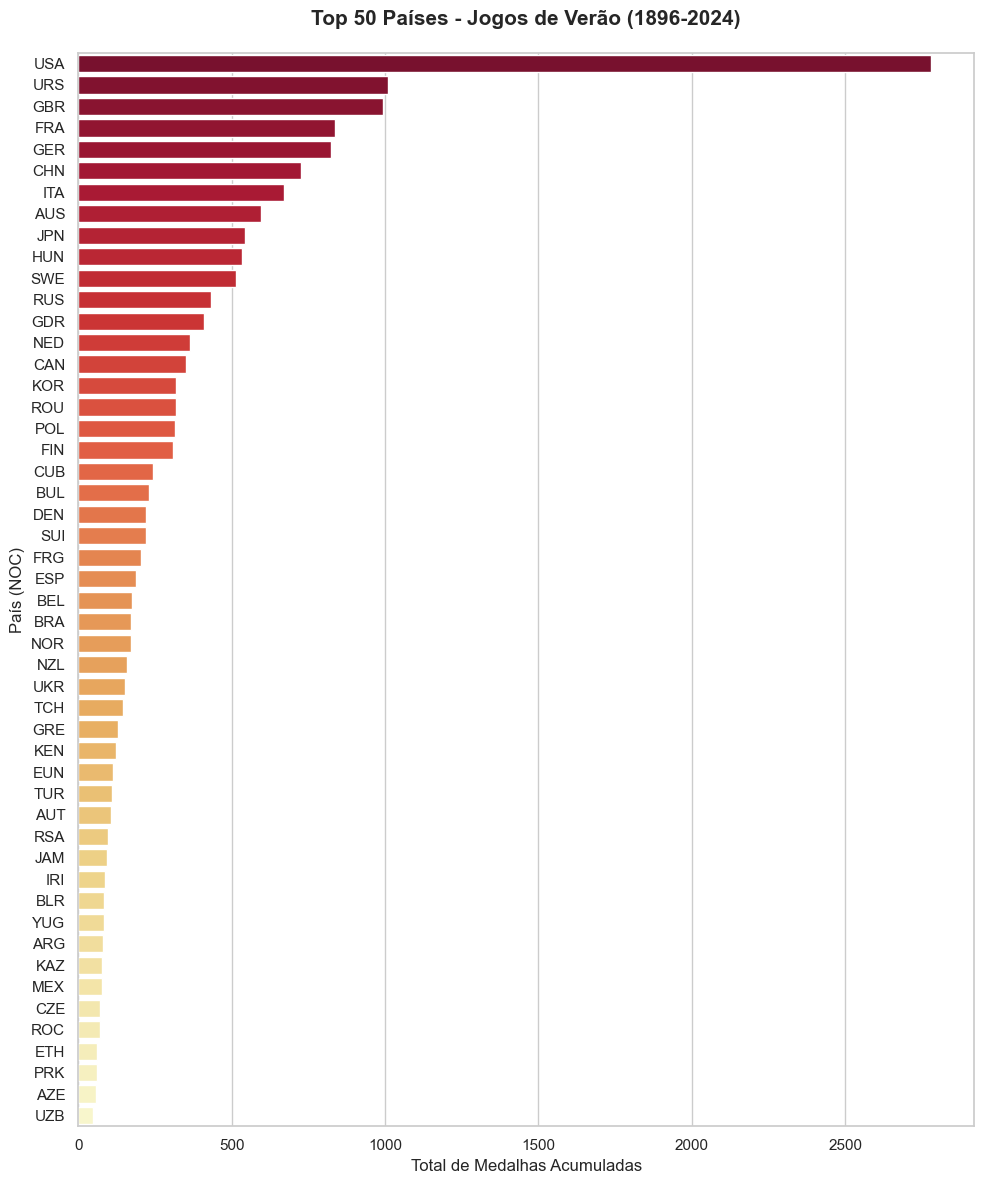

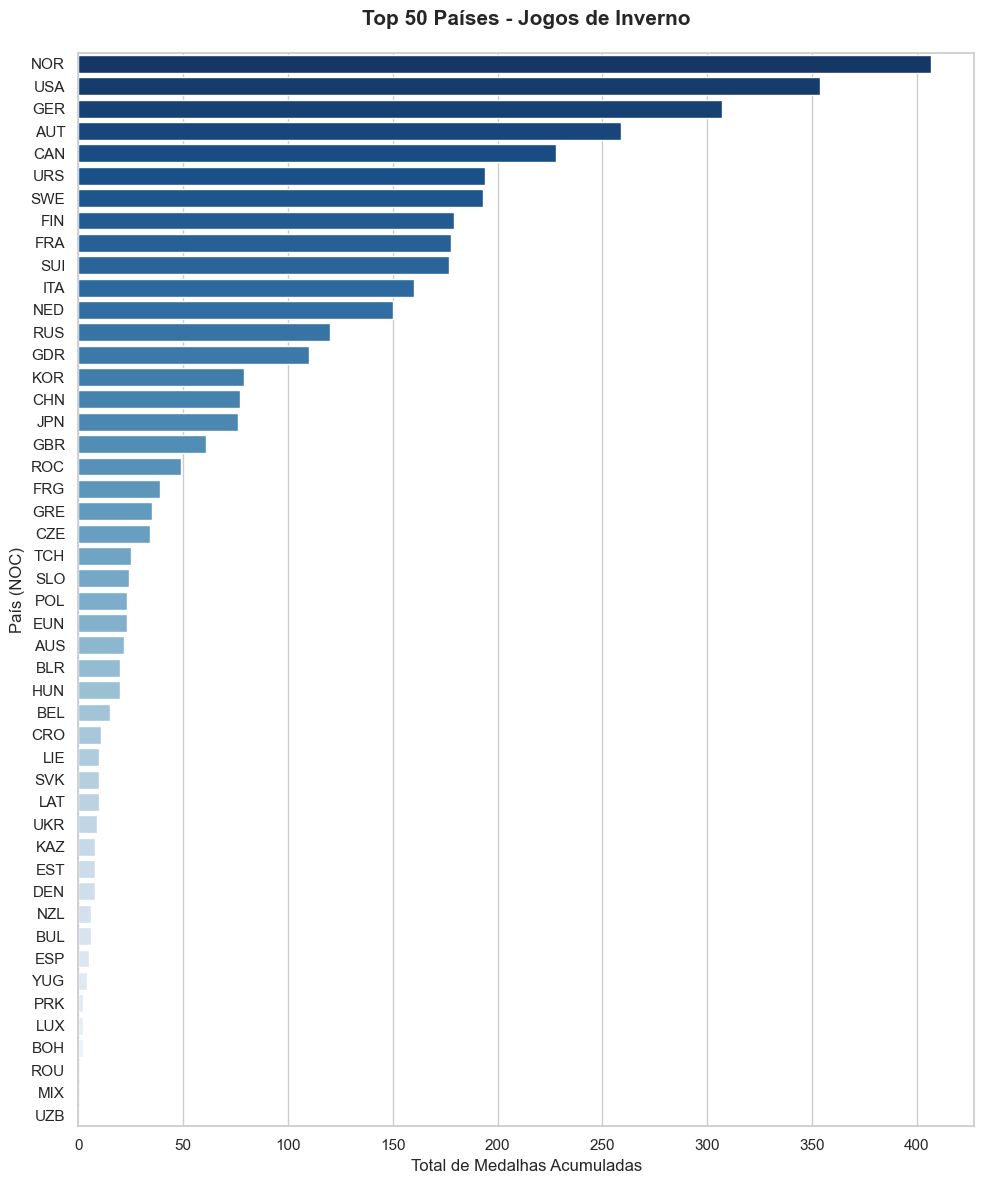

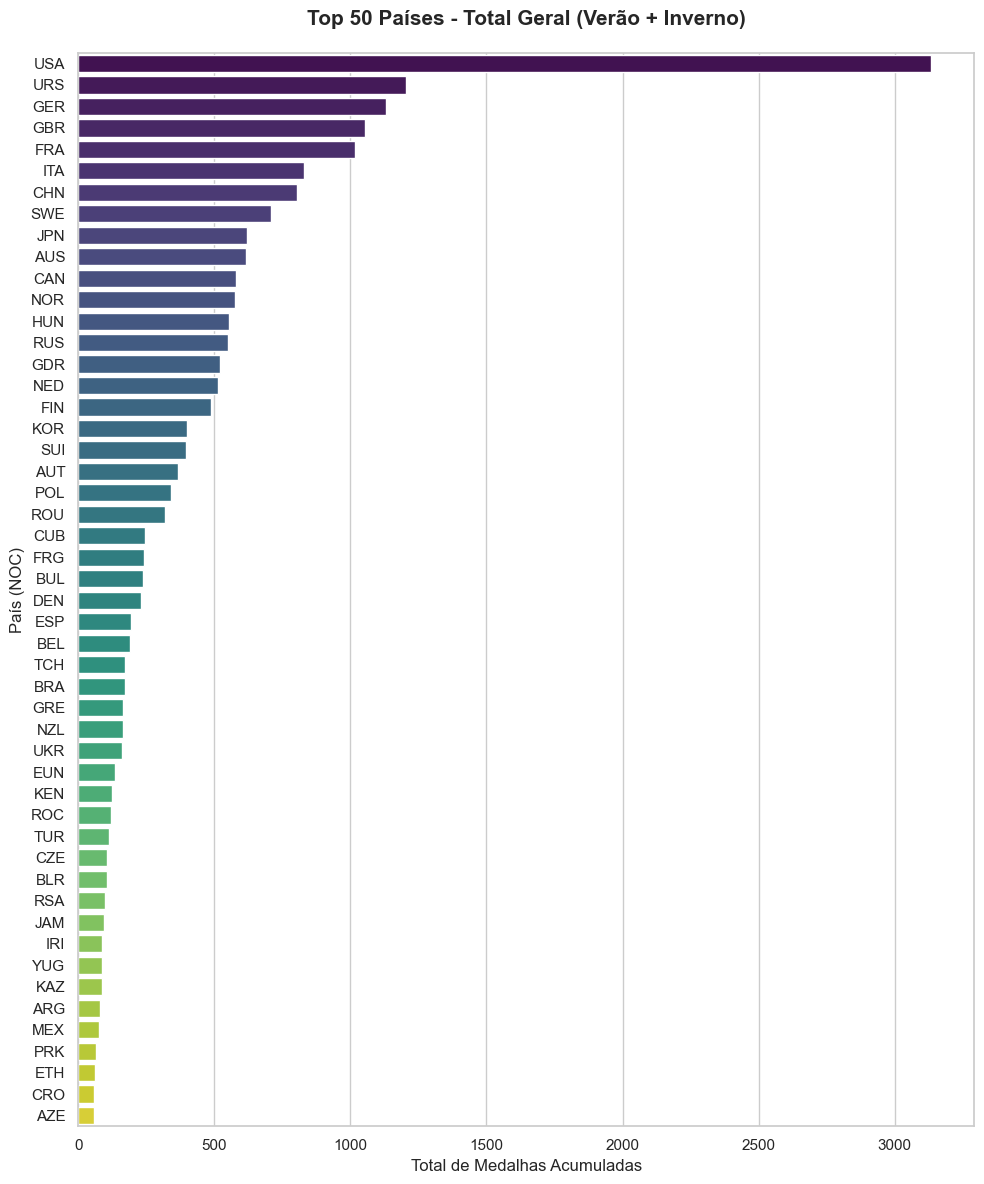

In [6]:
# Gráficos TOP50
def gerar_grafico_top50(df, titulo, paleta_cor):
    top_50 = df.head(50)
    plt.figure(figsize=(10, 12))
    sns.barplot(data=top_50, x='total', y='noc', palette=paleta_cor, hue='noc', legend=False)
    plt.title(titulo, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Total de Medalhas Acumuladas')
    plt.ylabel('País (NOC)')
    plt.tight_layout()
    plt.show()

gerar_grafico_top50(tabela_verao_final, "Top 50 Países - Jogos de Verão (1896-2024)", "YlOrRd_r")
gerar_grafico_top50(tabela_inverno_final, "Top 50 Países - Jogos de Inverno", "Blues_r")
gerar_grafico_top50(tabela_geral_final, "Top 50 Países - Total Geral (Verão + Inverno)", "viridis")

# Resetando configs de visualização
pd.reset_option('display.max_rows')